<a href="https://colab.research.google.com/github/bengisuyarimbas/HackAI/blob/main/MindTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install PyPDF2 sentence-transformers openai matplotlib nltk
!pip install pdfplumber
!pip install pymupdf
!apt install tesseract-ocr libtesseract-dev
!pip install pytesseract
!pip install transformers sentence_transformers openai matplotlib nltk pdfplumber pymupdf pytesseract
!apt install tesseract-ocr libtesseract-dev


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libtesseract-dev is already the newest version (4.1.1-2.1build1).
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libtesseract-dev is already the newest version (4.1.1-2.1build1).
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [ ]:
chat_history = []


In [ ]:
#Uploading Files
from google.colab import files
uploaded = files.upload()

Saving ltimindtree_annual_report.pdf to ltimindtree_annual_report (1).pdf


In [ ]:
# Getting the uploaded filename (assuming one file)
import io
import fitz  # PyMuPDF

# Automatically grab the uploaded file name
pdf_filename = list(uploaded.keys())[0]

# Open the PDF using PyMuPDF
doc = fitz.open(pdf_filename)
image_info_list = []

# Loop through pages and extract images
for page_num in range(len(doc)):
    for img_index, img in enumerate(doc.get_page_images(page_num)):
        xref = img[0]
        base_image = doc.extract_image(xref)
        image_info_list.append({
            "page": page_num + 1,
            "image_bytes": base_image["image"],
            "ext": base_image["ext"]
        })

print(f"✅ Extracted {len(image_info_list)} images from '{pdf_filename}'")


✅ Extracted 23 images from 'ltimindtree_annual_report (1).pdf'


In [ ]:
from PIL import Image
import pytesseract
import io
from sentence_transformers import SentenceTransformer # Import SentenceTransformer

# Load the SentenceTransformer model (if not already loaded)
model_embedding = SentenceTransformer("all-MiniLM-L6-v2")

for image_info in image_info_list:
    image = Image.open(io.BytesIO(image_info["image_bytes"]))
    text = pytesseract.image_to_string(image)
    image_info["ocr_text"] = text
    image_texts = [img["ocr_text"] for img in image_info_list if img.get("ocr_text")]
    image_chunks = []
for idx, img_info in enumerate(image_info_list):
    text = img_info.get("ocr_text", "")
    if text.strip():
        chunks = chunk_text(text)
        for i, chunk in enumerate(chunks):
            image_chunks.append({
                "text": chunk,
                "metadata": {"source": f"page {idx + 1}"},
                "image_path": img_info.get("image_path")  # optional, useful for BLIP
            })

    chunk_texts = [chunk["text"] for chunk in image_chunks]
    # Use the SentenceTransformer model for encoding
    image_embeddings = model_embedding.encode(chunk_texts, show_progress_bar=True)

def extract_text_from_image_bytes(image_bytes):
    image = Image.open(BytesIO(image_bytes))
    return pytesseract.image_to_string(image)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


NameError: name 'chunk_text' is not defined

In [ ]:
#Extratcting Financial Pages
from PyPDF2 import PdfReader

def extract_financial_pages(pdf_path, start_page=10, end_page=16):
    reader = PdfReader(pdf_path)
    pages = reader.pages[start_page-1:end_page]
    text = ''
    for page in pages:
        content = page.extract_text()
        if content:
            text += content + "\n"
    return text

pdf_path = list(uploaded.keys())[0]
financial_text = extract_financial_pages(pdf_path)

In [ ]:
#plit the Text into Chunks for Embedding & Q&A
import nltk

# Download the 'punkt' and 'punkt_tab' resources
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import sent_tokenize

def chunk_text(text, max_words=150):
    sentences = sent_tokenize(text)
    chunks = []
    chunk = []
    count = 0

    for sentence in sentences:
        chunk.append(sentence)
        count += len(sentence.split())

        if count >= max_words:
            chunks.append(" ".join(chunk))
            chunk = []
            count = 0

    if chunk:
        chunks.append(" ".join(chunk))
    return chunks

chunks = chunk_text(financial_text)
print(f"✅ Total Chunks Created: {len(chunks)}")

✅ Total Chunks Created: 26


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
#Embedding Chunks
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(chunks, show_progress_bar=True)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
'openai migrate'

'openai migrate'

In [ ]:
import openai

openai.api_key = "KEY""

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def search_chunks(query, embeddings, chunks, top_k=5):
    query_embedding = model.encode([query])
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    top_indices = similarities.argsort()[-top_k:][::-1]
    return [chunks[i] for i in top_indices]

In [ ]:
def generate_summary_with_memory(question, chunks, history):
    context = "\n\n".join(chunks)

    history_prompt = "\n".join([f"User: {q}\nAssistant: {a}" for q, a in history[-3:]])  # last 3 turns

    prompt = f"""
You are a smart financial assistant. Use the context below and the previous conversation to answer the current question.

Context:
{context}

Conversation so far:
{history_prompt}

User's current question:
{question}

Answer:"""

    # Use openai.chat.completions.create instead of openai.ChatCompletion.create
    response = openai.chat.completions.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=500,
        temperature=0.5
    )
    # Access the content using the 'choices' attribute and then accessing the 'message' and 'content' attributes
    return response.choices[0].message.content


#Auto-Visualize Numbers

In [ ]:
import re
import pdfplumber

def extract_tables_from_pdf(pdf_path, start=13, end=16):
    tables = []
    with pdfplumber.open(pdf_path) as pdf:
        for i in range(start - 1, end):  # zero-based index
            page = pdf.pages[i]
            page_tables = page.extract_tables()
            for table in page_tables:
                if table:  # filter out empty tables
                    tables.append(table)
    return tables

tables = extract_tables_from_pdf(pdf_path)
print(f"✅ Total Tables Found: {len(tables)}")




✅ Total Tables Found: 20


In [ ]:
import pandas as pd

# Pick a table that looks clean
sample_table = tables[0]  # try 1, 2, 3 if this isn't readable
df = pd.DataFrame(sample_table[1:], columns=sample_table[0])
df.head()

,"As at\nMarch 31, 2024"
0,
1,
2,"16,248"
3,"18,199"
4,"4,642"


In [ ]:
for idx, row in df.iterrows():
    print(f"{idx}: {row.tolist()}")

0: ['']
1: ['']
2: ['16,248']
3: ['18,199']
4: ['4,642']
5: ['6,286']
6: ['1,463']
7: ['127']
8: ['']
9: ['24,499']
10: ['66']
11: ['4,528']
12: ['2,014']
13: ['2,881']
14: ['1,808']
15: ['82,761']
16: ['']
17: ['30']
18: ['']
19: ['67,534']
20: ['53,721']
21: ['12,902']
22: ['15,947']
23: ['9,960']
24: ['456']
25: ['2,628']
26: ['249']
27: ['18,389']
28: ['181,816']
29: ['264,577']
30: ['']
31: ['']
32: ['296']
33: ['']
34: ['14,266']
35: ['178,422']
36: ['1']
37: ['192,985']
38: ['']
39: ['']
40: ['']
41: ['16,425']
42: ['318']
43: ['-']
44: ['157']
45: ['16,900']
46: ['']
47: ['']
48: ['']
49: ['118']
50: ['14,927']
51: ['2,894']
52: ['14,371']
53: ['13,105']
54: ['7,954']
55: ['1,323']
56: ['54,692']
57: ['71,592']
58: ['264,577']
59: ['']
60: ['']


In [ ]:
financial_headers = [
    "Property, Plant and Equipment",
    "Right-of-Use Assets",
    "Capital Work in Progress",
    "Goodwill",
    "Other Intangible Assets",
    "Intangible Assets under Development",
    "Investments",
    "Trade Receivables",
    "Other Financial Assets",
    "Deferred Tax Assets (Net)",
    "Income Tax Assets (Net)",
    "Other Non-current Assets",
    "Inventories",
    "Financial Investments (Current)",
    "Trade Receivables (Current)",
    "Unbilled Revenue",
    "Cash and Cash Equivalents",
    "Other Bank Balances",
    "Loans (Current)",
    "Other Financial Assets (Current)",
    "Income Tax Assets (Current)",
    "Other Current Assets",
    "TOTAL ASSETS"
]

In [ ]:
#Aligning Headers to Exctracted Values
import pandas as pd

# Extract only rows with numeric content (skip blank ones)
flat_rows = [row[0].replace(",", "") for row in df.values if row[0].strip() and row[0].replace(",", "").replace("-", "").strip().isdigit()]
# You may adjust slicing range depending on the actual number of rows extracted
data_2024 = flat_rows[:len(financial_headers)]

df_structured = pd.DataFrame({
    "Metric": financial_headers,
    "FY24 (INR Million)": data_2024
})

df_structured


,Metric,FY24 (INR Million)
0,"Property, Plant and Equipment",16248
1,Right-of-Use Assets,18199
2,Capital Work in Progress,4642
3,Goodwill,6286
4,Other Intangible Assets,1463
5,Intangible Assets under Development,127
6,Investments,24499
7,Trade Receivables,66
8,Other Financial Assets,4528
9,Deferred Tax Assets (Net),2014


In [ ]:
def detect_chart_intent(question):
    prompt = f"""
You're an assistant that classifies user questions.

If the question asks to show a chart, graph, plot, or visualize any metric, respond with only 'yes'.
Otherwise, respond with only 'no'.

Question: "{question}"
Answer:"""

    response = openai.chat.completions.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=5
    )
    return response.choices[0].message.content.strip().lower() == "yes"


In [ ]:
def ask_financial_assistant(question, save_dir="charts", model=None, chunks=None, embeddings=None):  # Add 'question' as a parameter
    print(f"🔎 Question: {question}\n")
    if detect_image_question(question):
        # Extract page number
        match = re.search(r'page\s+(\d+)', question.lower())
        target_page = int(match.group(1)) if match else None

        if target_page is not None:
            # Try captioning (BLIP)
            image_data = next((img for img in image_info_list if img["page"] == target_page), None)
            if image_data:
                image = Image.open(io.BytesIO(image_data["image_bytes"])).convert("RGB")
                inputs = processor(image, return_tensors="pt")
                out = model.generate(**inputs)
                caption = processor.decode(out[0], skip_special_tokens=True)
                result["summary"] = f"The image on page {target_page} likely shows: {caption}" # Assuming 'result' is defined somewhere
            else:
                result["summary"] = f"No image found on page {target_page}." # Assuming 'result' is defined somewhere

        else:
            # Fallback to OCR-based search if no page mentioned
            top_image_chunks = search_chunks(question, image_embeddings, image_chunks, model=model_st) # Assuming necessary variables are defined
            summary = generate_summary_with_memory(question, top_image_chunks, chat_history) # Assuming necessary variables are defined
            result["summary"] = "🖼️ Image-based content (OCR) says:\n" + summary # Assuming 'result' is defined somewhere


In [ ]:
def ask_financial_assistant(question, save_dir="charts", model=None, chunks=None, embeddings=None):
    os.makedirs(save_dir, exist_ok=True)

    result = {
        "summary": None,
        "chart_path": None
    }

    question_lower = question.lower()

    # === FORECAST DETECTION ===
    if "forecast" in question_lower or "expected" in question_lower or "fy25" in question_lower or "fy26" in question_lower:
        years_mentioned = []
        if "2025" in question_lower or "fy25" in question_lower:
            years_mentioned.append(2025)
        if "2026" in question_lower or "fy26" in question_lower:
            years_mentioned.append(2026)
        if not years_mentioned:
            years_mentioned = [2025, 2026]

        forecast_result = run_forecast_model()
        forecast_df = forecast_result["df"]

        summaries = []
        for year in years_mentioned:
            rev = forecast_df.loc[forecast_df['Year'] == year, 'Forecasted_Revenue_INR_Million'].values[0]
            prof = forecast_df.loc[forecast_df['Year'] == year, 'Forecasted_Net_Profit_INR_Million'].values[0]
            summaries.append(f"📈 Forecast for FY{str(year)[2:]}: Revenue = INR {rev:,.0f} million, Net Profit = INR {prof:,.0f} million.")
        result["summary"] = "\n".join(summaries)

        if any(word in question_lower for word in ["plot", "chart", "graph", "visualize"]):
            print("📊 Detected: Forecast chart requested.")
            filename = f"{uuid.uuid4().hex}.png"
            filepath = os.path.join(save_dir, filename)

            plot_df = forecast_df[forecast_df["Year"].isin(years_mentioned)]
            x = plot_df["Year"].astype(str)
            revenue = plot_df["Forecasted_Revenue_INR_Million"]
            profit = plot_df["Forecasted_Net_Profit_INR_Million"]

            plt.figure(figsize=(8, 5))
            width = 0.35
            indices = np.arange(len(x))

            plt.bar(indices - width / 2, revenue, width=width, label='Revenue', color='steelblue')
            plt.bar(indices + width / 2, profit, width=width, label='Net Profit', color='seagreen')

            plt.title("Forecasted Revenue and Net Profit")
            plt.xticks(indices, x)
            plt.ylabel("INR Million")
            plt.legend()
            plt.grid(True, axis='y', linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.savefig(filepath)
            plt.close()

            result["chart_path"] = filepath

        return result

    # === IMAGE CAPTIONING DETECTION ===
    if detect_image_question(question):
        print("🖼️ Detected: Image-related question.")

        if not chunks:
            result["summary"] = "No chunks available to analyze."
            return result

        image_chunks = [img for img in image_info_list if img.get("page") == 10]

        if not image_chunks:
            result["summary"] = "I couldn't find an image related to page 10."
            return result

        image_chunk = image_chunks[0]
        image_bytes = image_chunk.get("image_bytes")

        if image_bytes:
            raw_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
            inputs = processor(raw_image, return_tensors="pt")
            out = model_blip.generate(**inputs)
            caption = processor.decode(out[0], skip_special_tokens=True)

            result["summary"] = f"🖼️ Image Caption (Page 10): {caption}"
        else:
            result["summary"] = "I found a reference to an image on page 10, but no image data is available."

        return result

    # === TEXTUAL Q&A HANDLING ===
    if chunks is None or embeddings is None:
        return {"summary": "Error: Chunks or embeddings are not available.", "chart_path": None}

    top_chunks = search_chunks(question, embeddings, chunks, model=model_st)
    summary = generate_summary_with_memory(question, top_chunks, chat_history)
    result["summary"] = summary

    chat_history.append((question, summary))
    return result


Forecasting for Risk Management

In [ ]:
#Creating a dataframe woth historical data
import pandas as pd

data = {
    'Year': [2022, 2023, 2024],
    'Revenue_INR_Million': [156687, 331830, 355170],
    'Net_Profit_INR_Million': [22985, 44103, 45846]
}

df = pd.DataFrame(data)
chunks.append(f"Historical Revenue and Profit: {df.to_string(index=False)}")


In [ ]:
def detect_forecast_intent(question):
    keywords = ["forecast", "predict", "projection", "estimate", "future revenue", "next 2 years"]
    return any(kw in question.lower() for kw in keywords)

In [ ]:
#Building the FOrecasting Model
from sklearn.linear_model import LinearRegression
import numpy as np

# Forecast Revenue
X = df[['Year']]
y_revenue = df['Revenue_INR_Million']
model_revenue = LinearRegression().fit(X, y_revenue)

# Forecast Net Profit
y_profit = df['Net_Profit_INR_Million']
model_profit = LinearRegression().fit(X, y_profit)

# Predict for FY25 and FY26
future_years = pd.DataFrame({'Year': [2025, 2026]})
revenue_predictions = model_revenue.predict(future_years)
profit_predictions = model_profit.predict(future_years)

# Combine predictions
forecast_df = future_years.copy()
forecast_df['Forecasted_Revenue_INR_Million'] = revenue_predictions.round()
forecast_df['Forecasted_Net_Profit_INR_Million'] = profit_predictions.round()


Information Retrieving and Summarizing


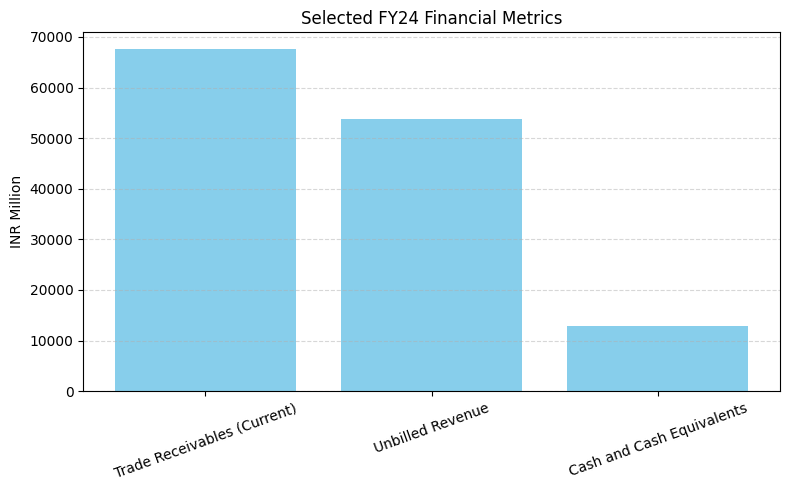

In [ ]:
plot_df = df_structured[df_structured["Metric"].isin([
    "Unbilled Revenue",
    "Cash and Cash Equivalents",
    "Trade Receivables (Current)"
])]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Metric"], plot_df["FY24 (INR Million)"].astype(int), color="skyblue")
plt.title("Selected FY24 Financial Metrics")
plt.ylabel("INR Million")
plt.xticks(rotation=20)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
user_question = "Summarize the company's profit, revenue, and growth performance this year"

top_chunks = search_chunks(user_question, embeddings, chunks)
summary_response = generate_summary_with_memory(user_question, top_chunks, chat_history)

print("📊 Insight Summary:\n")
print(summary_response)

📊 Insight Summary:

The company's performance for the year ended March 31, 2024, shows positive growth and profitability. The revenue from operations increased from 319,755 million in the previous year to 342,534 million. Other income also saw a rise from 5,016 million to 7,099 million, making the total income for the year 349,633 million, up from 324,771 million in the previous year.

The company's net profit after tax also increased from 42,482 million to 44,859 million. The total comprehensive income, which includes other comprehensive income/loss, increased significantly from 35,648 million to 49,708 million. This suggests a strong growth in the company's overall financial performance.

The basic earning per equity share increased from 143.66 to 151.60, and the diluted earning per equity share increased from 143.43 to 151.24, indicating a growth in the company's earnings per share. 

The increase in these key financial metrics indicates a positive growth performance for the company

Forecasting


In [ ]:
response = ask_financial_assistant("What is the forecast for FY25 and FY26?" , chunks=chunks, embeddings=embeddings, model=model_blip)
print("📊 Summary:\n", response["summary"])
print("📈 Forecast Chart:", response["chart_path"])

NameError: name 'model_blip' is not defined

#Image Interpretation

In [ ]:
response = ask_financial_assistant(
    "What does the image on page 10 show?",
    chunks=chunks,
    embeddings=embeddings,
    model=model_blip
)

print(response["summary"])

NameError: name 'model_blip' is not defined

In [ ]:
response = ask_financial_assistant("Forecast revenue and net profit for the next 2 years")

print("📝 Summary:")
print(response["summary"])

print("🖼️ Chart image saved at:")
print(response["chart_path"])


NameError: name 'os' is not defined